<a href="https://colab.research.google.com/github/dylanvisor-alt/Group9_3009ICT_Group_Assignment/blob/dylan-charts/Group9_3009ICT_DataProcessingVisualisation_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Processing and Visualization
-----
**Assignment Topic: Data Analysis on Car Advertisements**


Student1 Name: **Dylan Smith**

SNumber: **S5394318**

Student2 Name: **Dion Kircher**

SNumber **S5399878**

**Data Exploration and Cleaning — Outliers & Missing Values**

This section detects outliers using the IQR method and decides for each variable whether outliers should be removed, retained, or transformed, and then identifies and treats missing values across the dataset. Statistics are reported before and after cleaning so the effect of each decision is visible.


**Outlier detection (IQR method)**

For price, mileage, and year_of_manufacture, Q1 and Q3 are calculated and the interquartile range (IQR = Q3 − Q1) is used to set bounds at Q1 − 1.5×IQR and Q3 + 1.5×IQR. Values outside these bounds are statistically unusual but it doesnt require its removal. Each variable is handled differntly given the circumstances.

Some of the lower bounds like the IQR lower bounds for price (≈ −19,676) and mileage (−90,000) are negative and therefore cannot identify any false observations, since neither price nor mileage can be below zero. Invalid low values are instead handled with rules like price < 1 and implausible zero mileages described later on.

**Price — retain high, remove invalid low**

High-price IQR outliers above the upper bound (≈ 76,518 dollars) are retained. 3,767 records sit above it, but the high prices legitimately represent luxury cars rather than errors upon manual inspection, and removing them would bias the dataset toward only ordinary cars. Separately, 172 records priced below 1 dollar, which shouldn't be a true sale are removed as a near-zero prices (e.g. ≈ 0.00004 dollars). To confirm the threshold is not letting cars that might cost between 1 and 100 dollars through, I inspected the 20 prices after the data was cleaned and the lowest was ≈ 729 dollars for a 1996 Kia Pride, and the rest are old, low-value economy cars and are plausible and therefore no further low price cleaning was made.

**Mileage — retain, transform, and impute**

Mileage required the most treatment because it contains three problems:


*   High values above the IQR upper bound (150,000 km): the upper bound identifies statistically unusual mileages, but high mileage is not inherently invalid because an older car can legitimately exceed it. Values between 150,000 and 500,000 km are therefore retained.


*   Impossible high values (> 500,000 km): 253 values exceed this threshold are mostly implausible for a car to complete and manual inspection of cars above 500,000 seemed illegitimate. Some are corrupted entries most notably the 4,294,967,295, being the maximum unsigned 32-bit integer (2³²−1). All of these values were transformed to missing and later imputed.

*   Zero mileages: a large number of listings recorded  0 km. The newest model year in the dataset is 2023, so the data was collected around that time. Zero mileage cars from 2022–2023 are retained as plausibly new or unsold stock (6,117 records, 20.1% of rows), while zero-mileage cars from 2021 or earlier are treated as unrecorded mileage (4,254 records), set to missing and imputed. The retained zeros are concentrated in the newest model years (3,988 from 2023 and 2,129 from 2022), which supports treating them as genuinely new rather than errors.


All values set to missing in this step (4,254 implausible zeros + 253 impossible highs = 4,507) are imputed with the median (30,000 km). The median is chosen over the mean because mileage is right-skewed, making the median the more accurate centre, and because imputing with the median barely shifts the column's centre.

A portion of the retained 2022–2023 zeros may themselves be unreported rather than genuinely new, but at that age genuine-new and unreported cannot be reliably distinguished and as a result the mileage mode remains 0 and mileage statistics may be slightly biased downward. After imputation, 5,090 rows (16.7% of the column) sit at exactly 30,000 km with the 4,507 imputed rows plus any genuine 30,000 km readings. All of these records will appear as a spike in any mileage distribution or mileage vs price chart and as a result imputation, and not a real pattern or trend. Imputation was chosen over deletion so that the other valid fields of these rows (price, brand, year) are preserved for the rest of the analysis.

**Year of manufacture — retain outliers, median impute**

842 year outliers fall outside the IQR bounds. These are all retained, as both old and new vehicles are legitimate listings and removing them would bias the dataset. The 29 missing year values are imputed with the median (2019), which is the appropriate measure for an ordered numerical variable.

**Categorical columns — mode or Unknown depending on missingness**

Low missingness categorical columns are imputed with the mode, the only appropriate measure for categorical data: exterior_color (17 → White), interior_color (857 → Black), transmission (15 → Automatic), drive_type (107 → FWD), and engine (24 → Petrol 2.0 L). By contrast, fuel_system (≈78% missing) and fuel_consumption (≈63% missing) are set to "Unknown" rather than imputed because filling a mode across the majority of a column would fabricate the bulk of the data from a small sample of true values and therefore misrepresenting the dataset.


# 0. Data Import

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import sqlite3
import numpy as np
import seaborn as sns

In [ ]:
car_data = pd.read_csv("/content/car_dataset.csv")
sellers_data = pd.read_csv("/content/seller_dataset.csv")

# 1. Data Formatting

## a. Numerical Conversion

In [ ]:
raw_check = pd.read_csv("/content/car_dataset.csv")
print(raw_check['fuel_consumption'].head(10))

# mileage
car_data['mileage'] = car_data['mileage'].astype(str).str.replace('Km', '', regex=False).str.replace(',', '', regex=False).astype(int)

# price
car_data['price (AUD)'] = car_data['price (AUD)'].astype(str).str.replace('[$,]', '', regex=True).astype(float)

# num_of_doors
car_data['num_of_doors'] = car_data['num_of_doors'].astype(str).str.extract(r'(\d+)').astype(int)

# seating_capacity
car_data['seating_capacity'] = car_data['seating_capacity'].astype(str).str.extract(r'(\d+)').astype(int)

# fuel_consumption
car_data['fuel_consumption'] = car_data['fuel_consumption'].astype(str).str.split('\t').str[0]
car_data['fuel_consumption'] = pd.to_numeric(car_data['fuel_consumption'], errors='coerce')

# verify all 5 columns converted correctly
print(car_data[['mileage', 'price (AUD)', 'num_of_doors', 'seating_capacity', 'fuel_consumption']].dtypes)
print(car_data[['mileage', 'price (AUD)', 'num_of_doors', 'seating_capacity', 'fuel_consumption']].head(10))
print(car_data['fuel_consumption'].isnull().sum(), "missing values")



0        L/100Km
1    10\tL/100Km
2        L/100Km
3        L/100Km
4        L/100Km
5     7\tL/100Km
6        L/100Km
7        L/100Km
8     7\tL/100Km
9     7\tL/100Km
Name: fuel_consumption, dtype: object
mileage               int64
price (AUD)         float64
num_of_doors          int64
seating_capacity      int64
fuel_consumption    float64
dtype: object
   mileage   price (AUD)  num_of_doors  seating_capacity  fuel_consumption
0        0   10080.99411             2                 2               NaN
1        0  161943.68050             5                 7              10.0
2        0   35830.03930             5                 8               NaN
3        0   30526.38376             5                 5               NaN
4        0   34413.03209             5                 8               NaN
5        0   12105.29011             5                 2               7.0
6        0   39838.14539             5                 7               NaN
7        0   40485.92011             5

## b. Engine Feature Split

In [ ]:
print(car_data['engine'].head(10))

# split on the tab character into two new columns
car_data[['type_of_engine', 'engine_capacity']] = car_data['engine'].str.split('\t', expand=True)

# capacity: remove "L" and convert to float
car_data['engine_capacity'] = car_data['engine_capacity'].str.replace(' L', '', regex=False).astype(float)

# verify
print(car_data[['engine', 'type_of_engine', 'engine_capacity']].head(10))
print(car_data['engine_capacity'].dtype)

0    Petrol\t1.0 L
1    Petrol\t3.4 L
2    Petrol\t2.0 L
3    Petrol\t1.8 L
4    Petrol\t2.0 L
5    Petrol\t1.0 L
6    Petrol\t1.5 L
7    Petrol\t2.7 L
8    Diesel\t2.2 L
9    Diesel\t2.2 L
Name: engine, dtype: object
          engine type_of_engine  engine_capacity
0  Petrol\t1.0 L         Petrol              1.0
1  Petrol\t3.4 L         Petrol              3.4
2  Petrol\t2.0 L         Petrol              2.0
3  Petrol\t1.8 L         Petrol              1.8
4  Petrol\t2.0 L         Petrol              2.0
5  Petrol\t1.0 L         Petrol              1.0
6  Petrol\t1.5 L         Petrol              1.5
7  Petrol\t2.7 L         Petrol              2.7
8  Diesel\t2.2 L         Diesel              2.2
9  Diesel\t2.2 L         Diesel              2.2
float64


## c. Standardizing Text Data

In [ ]:
categorical_cols = ['origin', 'condition', 'car_model', 'exterior_color', 'interior_color', 'type_of_engine', 'fuel_system', 'transmission', 'drive_type', 'brand', 'grade']

# lowercase all entries in data colums
for col in categorical_cols:
  car_data[col] = car_data[col].astype(str).str.lower()

# one-hot encode
car_data_encoded = pd.get_dummies(car_data, columns=categorical_cols)

# verify
print(car_data[categorical_cols].head(5))
print(car_data_encoded.shape)
print(car_data_encoded.columns.tolist()[:30])


              origin condition  car_model exterior_color interior_color  \
0  domestic assembly   new car      truck          white           gray   
1           imported   new car        suv          black          black   
2  domestic assembly   new car  crossover         silver          brown   
3           imported   new car        suv          white          black   
4  domestic assembly   new car  crossover         silver           gray   

  type_of_engine fuel_system transmission                 drive_type   brand  \
0         petrol         nan       manual     rfd - rear-wheel drive  suzuki   
1         petrol         nan    automatic  awd - 4-wheel drive (awd)  toyota   
2         petrol         nan    automatic     rfd - rear-wheel drive  toyota   
3         petrol         nan    automatic    fwd - front-wheel drive  toyota   
4         petrol         nan    automatic     rfd - rear-wheel drive  toyota   

               grade  
0  super carry truck  
1       land cruiser  

In [ ]:
# diagnostic step

for col in categorical_cols:
  print(col, car_data[col].nunique())

origin 2
condition 2
car_model 10
exterior_color 18
interior_color 18
type_of_engine 5
fuel_system 686
transmission 4
drive_type 6
brand 76
grade 479


## d. Standardising Text Data




In [ ]:
categorical_cols = ['origin', 'condition', 'car_model', 'exterior_color', 'interior_color', 'type_of_engine', 'fuel_system', 'transmission', 'drive_type', 'brand', 'grade']

for col in categorical_cols:
  car_data[col] = car_data[col].where(car_data[col].isna(), car_data[col].astype(str).str.lower())

for col in categorical_cols:
  print(col, car_data[col].nunique())

from sklearn.preprocessing import LabelEncoder

onehot_cols = ['origin', 'condition', 'car_model', 'exterior_color', 'interior_color', 'type_of_engine', 'transmission', 'drive_type']
label_cols = ['fuel_system', 'brand', 'grade']

car_data_encoded = pd.get_dummies(car_data, columns = onehot_cols)

for col in label_cols:
  car_data_encoded[col +'_encoded'] = LabelEncoder().fit_transform(car_data_encoded[col].astype(str))

# verify
print(car_data_encoded.shape)

origin 2
condition 2
car_model 10
exterior_color 18
interior_color 18
type_of_engine 5
fuel_system 686
transmission 4
drive_type 6
brand 76
grade 479
(30652, 81)


## e. Numerical Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

cols_to_scale = ['engine_capacity', 'num_of_doors', 'seating_capacity', 'fuel_consumption', 'price (AUD)']
new_col_names = ['normalised_engine_capacity', 'normalised_num_of_doors', 'normalised_seating_capacity', 'normalised_fuel_consumption', 'normalised_price']

car_data_encoded[new_col_names] = scaler.fit_transform(car_data_encoded[cols_to_scale])

print(car_data_encoded[new_col_names].describe())

       normalised_engine_capacity  normalised_num_of_doors  \
count                29285.000000             30652.000000   
mean                     0.154511                 0.083388   
std                      0.064822                 0.017643   
min                      0.000000                 0.000000   
25%                      0.111111                 0.074074   
50%                      0.150794                 0.092593   
75%                      0.182540                 0.092593   
max                      1.000000                 1.000000   

       normalised_seating_capacity  normalised_fuel_consumption  \
count                 30652.000000                 11423.000000   
mean                      0.117872                     0.000178   
std                       0.033670                     0.010477   
min                       0.000000                     0.000000   
25%                       0.106383                     0.000030   
50%                       0.106383     

# 2. Data Exploration and Cleaning

## a. Statistics Computation

In [ ]:
# cleans mileage by removing Km and converting it into an integer
car_data['mileage'] = car_data['mileage'].astype(str).str.replace(' Km', '', regex=False).str.replace(',', '', regex=False).astype(int)

# number of rows
preprocessed_car_data_length = len(car_data)
print("Number of rows in Preprocessed car data:" , preprocessed_car_data_length)

# mean
price_mean = car_data['price (AUD)'].mean()
mileage_mean = car_data['mileage'].mean()
year_of_m_mean = car_data['year_of_manufacture'].mean()
print("Mean/Average of price" , price_mean)
print("Mean/Average of mileage" , mileage_mean)
print("Mean/Average of year of manufacture" , year_of_m_mean)

# media
median_price = car_data['price (AUD)'].median()
median_mileage = car_data['mileage'].median()
median_year_of_m = car_data['year_of_manufacture'].median()
print("Median of price" , median_price)
print("Median of mileage" , median_mileage)
print("Median of year of manufacture" , median_year_of_m)

# mode
mode_price = car_data['price (AUD)'].mode()
mode_mileage = car_data['mileage'].mode()
mode_year_of_m = car_data['year_of_manufacture'].mode()
print("Mode of price" , mode_price)
print("Mode of mileage" , mode_mileage)
print("Mode of year of manufacture" , mode_year_of_m)

# std dev
std_price = car_data['price (AUD)'].std()
std_mileage = car_data['mileage'].std()
std_year_of_m = car_data['year_of_manufacture'].std()
print("Standard Deviation of price" , std_price)
print("Standard Deviation of mileage" , std_mileage)
print("Standard Deviation of year of manufacture" , std_year_of_m)

# range
range_price = car_data['price (AUD)'].max() - car_data['price (AUD)'].min()
range_mileage = car_data['mileage'].max() - car_data['mileage'].min()
range_year_of_m = car_data['year_of_manufacture'].max() - car_data['year_of_manufacture'].min()
print("Range of price" , range_price)
print("Range of mileage" , range_mileage)
print("Range of year of manufacture" , range_year_of_m)

Number of rows in Preprocessed car data: 30652
Mean/Average of price 42843.1577475494
Mean/Average of mileage 412315.0327547958
Mean/Average of year of manufacture 2017.320346178968
Median of price 24939.32679
Median of mileage 20000.0
Median of year of manufacture 2019.0
Mode of price 0    40485.92011
Name: price (AUD), dtype: float64
Mode of mileage 0    0
Name: mileage, dtype: int64
Mode of year of manufacture 0    2023.0
Name: year_of_manufacture, dtype: float64
Standard Deviation of price 78585.5882423947
Standard Deviation of mileage 34899663.67076805
Standard Deviation of year of manufacture 5.3317724314591874
Range of price 2186239.6859595003
Range of mileage 4294967295
Range of year of manufacture 33.0


Statistics Computation — Before Cleaning

This section calculates the five required statistics (mean, median, mode, standard deviation, range) for price (AUD), mileage, and year_of_manufacture. These statistics are calculated twice: once on the raw data below (before outlier and missing-value treatment) and again after cleaning, so the effect of the cleaning process can be seen.

The raw mileage statistics are heavily distorted by invalid values. The mean (≈412,315 km), standard deviation (≈34.9 million), and range (4,294,967,295) are inflated by placeholder and corrupted entries most notably the value 4,294,967,295 which is the maximum unsigned 32-bit integer (2³²−1) and could represents a data-export error. Mileage also has a mode and 25th percentile of 0, indicating a large number of zero-mileage listings. These issues are addressed in the outlier and missing-value treatment that follows, after which the statistics are recomputed on the cleaned data.

## b. Outliers and Missing Values

In [ ]:
car_data['mileage'] = car_data['mileage'].astype(str).str.replace(' Km', '', regex=False).str.replace(',', '', regex=False).astype(int)

# CALCULATING INTER-QUARTILE RANGES
print()
# price
price_Q1 = car_data['price (AUD)'].quantile(0.25)
price_Q3 = car_data['price (AUD)'].quantile(0.75)
price_IQR = price_Q3 - price_Q1
print("Q1 of price" , price_Q1)
print("Q3 of price" , price_Q3)
print("IQR of price" , price_IQR)

# mileage
mileage_Q1 = car_data['mileage'].quantile(0.25)
mileage_Q3 = car_data['mileage'].quantile(0.75)
mileage_IQR = mileage_Q3 - mileage_Q1
print("Q1 of mileage" , mileage_Q1)
print("Q3 of mileage" , mileage_Q3)
print("IQR of mileage" , mileage_IQR)

# year of manufacture
year_of_m_Q1 = car_data['year_of_manufacture'].quantile(0.25)
year_of_m_Q3 = car_data['year_of_manufacture'].quantile(0.75)
year_of_m_IQR = year_of_m_Q3 - year_of_m_Q1
print("Q1 of year of manufacture" , year_of_m_Q1)
print("Q3 of year of manufacture" , year_of_m_Q3)
print("IQR of year of manufacture" , year_of_m_IQR)


# CALCULATING LOWER AND UPPER BOUNDS
print()
# price
price_lb = price_Q1 - (1.5 * price_IQR)
price_ub = price_Q3 + (1.5 * price_IQR)
print("Lower Bound of price" , price_lb)
print("Upper Bound of price" , price_ub)

# mileage
mileage_lb = mileage_Q1 - (1.5 * mileage_IQR)
mileage_ub = mileage_Q3 + (1.5 * mileage_IQR)
print("Lower Bound of mileage" , mileage_lb)
print("Upper Bound of mileage" , mileage_ub)

# year of manufacture
year_of_m_lb = year_of_m_Q1 - (1.5 * year_of_m_IQR)
year_of_m_ub = year_of_m_Q3 + (1.5 * year_of_m_IQR)
print("Lower Bound of year of manufacture" , year_of_m_lb)
print("Upper Bound of year of manufacture" , year_of_m_ub)



# CALCULATING OUTLIERS
print()
# price
price_outliers = car_data[
    (car_data['price (AUD)'] < price_lb) |
    (car_data['price (AUD)'] > price_ub)
]
print("Number of prices outside of upper and lower bounds:", len(price_outliers))

# mileage
mileage_outliers = car_data[
    (car_data['mileage'] < mileage_lb) |
    (car_data['mileage'] > mileage_ub)
]
print("Number of mileages outside of upper and lower bounds:", len(mileage_outliers))

#year of manufacture
year_of_m_outliers = car_data[
    (car_data['year_of_manufacture'] < year_of_m_lb) |
    (car_data['year_of_manufacture'] > year_of_m_ub)
]
print("Number of year of manufacture outside of upper and lower bounds:", len(year_of_m_outliers))

#display(price_outliers.sort_values('price (AUD)', ascending=False).head(5))
#display(price_outliers.sort_values('price (AUD)', ascending=False).tail(5))
#display(mileage_outliers.sort_values('mileage', ascending=False).head(20)) #something like the top 100 are invalid for the highest mileage
#display(mileage_outliers.sort_values('mileage', ascending=False).tail(5))
#display(year_of_m_outliers.sort_values('year_of_manufacture').head(5))
#display(year_of_m_outliers.sort_values('year_of_manufacture').tail(5))



# CLEANING THE DATA
print()
cleaned_car_data = car_data.copy(deep=True)

# Store the initial number of rows before cleaning
before_cleaning_rows = len(cleaned_car_data)

# records specific columns with missing values
placeholder_columns = ['exterior_color','interior_color','engine','fuel_system','transmission','drive_type']

# converts placeholders into missing values
for column in placeholder_columns:
    cleaned_car_data[column] = (cleaned_car_data[column].astype('string').str.strip().replace('-', pd.NA))

# cleans the L/100Km from the fuel-consumption column
cleaned_car_data['fuel_consumption'] = (cleaned_car_data['fuel_consumption'].astype('string').str.strip())
cleaned_car_data.loc[cleaned_car_data['fuel_consumption'] == 'L/100Km','fuel_consumption'] = pd.NA

# counts missing values in every column
missing_before = cleaned_car_data.isna().sum()

# calculate percentage of missing values
missing_percentage_before = (missing_before / len(cleaned_car_data)) * 100

# creates the misssing values and missing percentages table
missing_summary_before = pd.DataFrame({'Missing Count': missing_before,'Missing Percentage': missing_percentage_before})

# displays the missing summary table
display(missing_summary_before[missing_summary_before['Missing Count'] > 0].sort_values('Missing Count',ascending=False))



# PRICE OUTLIER AND INVALID-VALUE CLEANING
print()
print("Rows before invalid price removal:",len(cleaned_car_data))

# IQR price outliers above the upper bound are retained because many represent legitimate high value cars
price_iqr_outliers = cleaned_car_data[cleaned_car_data['price (AUD)'] > price_ub]
print("High-price IQR outliers retained:",len(price_iqr_outliers))


# checks for prices < AUD 1 are treated as invalid.
invalid_lower_price = cleaned_car_data['price (AUD)'] < 1
print("Invalid price values removed where its less than a dollar:", invalid_lower_price.sum())

# Store removed rows before filtering
removed_price_rows = cleaned_car_data[invalid_lower_price].copy()

# remove only the clearly invalid price records
cleaned_car_data = cleaned_car_data[~invalid_lower_price].copy()
print("Rows after invalid price removal:",len(cleaned_car_data))
print("Examples of invalid prices removed:")
display(removed_price_rows[['ad_id', 'brand', 'car_name', 'year_of_manufacture', 'price (AUD)']].sort_values('price (AUD)').head(10))

# inspect the low end of price after the <$1 removal, to check nothing invalid slipped through (nothing seemingly invalid)
print("20 smallest prices after invalid-price removal:")
display(cleaned_car_data[['ad_id','brand','car_name','year_of_manufacture','price (AUD)']].sort_values('price (AUD)').head(20))



# MILEAGE OUTLIER CLEANING
print()
# IQR outliers identified using mileage_ub
mileage_iqr_outliers = cleaned_car_data[cleaned_car_data['mileage'] > mileage_ub]
print("Mileages above upper bound:",len(mileage_iqr_outliers))

# calculating the median from valid mileages
mileage_median_before_outliers = cleaned_car_data['mileage'].median()
print("Median mileage used for imputation:",mileage_median_before_outliers)

# The IQR upper bound of 150,000 km was used to identify statistically unusual mileages but not impossible values
# however higher mileage vehicles above this value seemed legitimate and upon further inspection, values after 500000
# km were very round numbers and therefore transformed and a few even contain the maximum unsigned 32-bit integer (2^32−1)
invalid_mileages = cleaned_car_data['mileage'] > 500000
print("Mileage values > 500,000 km to be transformed:",invalid_mileages.sum())

# The mode and Q1 of the milage is 0 and therefore we should cut off at 2-3 years after the year the dataset was collected
print("Latest manufactured car:", car_data['year_of_manufacture'].max()) # this says the latest car manufactured was 2023

# Given the latest car was manufacture in 2023, this data was probably acquired in 2023. In decinding a cut off date
# it is very possible a car could have possily been manufactured in 2022 but not driven due to transportation though exports
# or could be unsold stock and thefore the cut off will be 2021 or earlier

# how many 0-km cars fall under the rule of 2021 or earlier
mileage_zero_old = (cleaned_car_data['mileage'] == 0) & (cleaned_car_data['year_of_manufacture'] <= 2021)
print("Zero-mileage cars, 2021 or earlier (to be imputed):", mileage_zero_old.sum())

# how many 0-km cars are retained as plausibly new in 2022-2023
mileage_zero_new = (cleaned_car_data['mileage'] == 0) & (cleaned_car_data['year_of_manufacture'] >= 2022)
print("Zero-mileage cars, 2022-2023 (retained as genuinely new):", mileage_zero_new.sum())

# retained zero-mileage cars
zero_retained_count = mileage_zero_new.sum()
zero_retained_pct = (zero_retained_count / len(cleaned_car_data)) * 100
print(f"Zero-mileage cars retained (2022-2023): {zero_retained_count} ({zero_retained_pct:.1f}% of rows)")

# breakdown by year so its clearer these are concentrated in the newest model years
print("Retained zero-mileage cars by year: ", cleaned_car_data[mileage_zero_new]['year_of_manufacture'].value_counts().sort_index())


# savings 0 mileage examples
zero_old_examples = cleaned_car_data[mileage_zero_old][['ad_id','brand','car_name','year_of_manufacture','mileage']].copy()

# cleaning 0 mileages
cleaned_car_data.loc[mileage_zero_old, 'mileage'] = np.nan
print("Implausible zero mileages (<=2021) set to NaN for imputation:", mileage_zero_old.sum())


# saving examples before transforming them
transformed_mileage_rows = cleaned_car_data[invalid_mileages][['ad_id', 'brand', 'car_name', 'year_of_manufacture', 'mileage']].copy()

# transforming high invalid mileages to missing
cleaned_car_data.loc[invalid_mileages,'mileage'] = np.nan
print("Examples of 5 of the top and bottom end of high invalid mileages transformed:")
display(transformed_mileage_rows[['ad_id', 'brand', 'car_name', 'year_of_manufacture', 'mileage']].sort_values('mileage', ascending=False).head(5))
display(transformed_mileage_rows[['ad_id', 'brand', 'car_name', 'year_of_manufacture', 'mileage']].sort_values('mileage', ascending=False).tail(5))

# calculating the median from valid mileages after the invalid values have been transformed to NaN.
mileage_median_after_outliers = cleaned_car_data['mileage'].median()
print("Median mileage used for imputation for :",mileage_median_after_outliers)

# replaced the newly missing mileage values with the median
cleaned_car_data['mileage'] = cleaned_car_data['mileage'].fillna(mileage_median_after_outliers)

# shows how many rows are now the imputed median
imputed_to_median = (cleaned_car_data['mileage'] == mileage_median_after_outliers).sum()
imputed_percent = (imputed_to_median / len(cleaned_car_data)) * 100
print(f"Rows now at the imputed median ({mileage_median_after_outliers:,.0f} km): {imputed_to_median} ({imputed_percent:.1f}% of column)")



# YEAR OUTLIER AND MISSING VALUE CLEANING
print()
# IQR outliers identified using year_of_m_ub
year_iqr_outliers_retained = cleaned_car_data[(cleaned_car_data['year_of_manufacture'] < year_of_m_lb) |(cleaned_car_data['year_of_manufacture'] > year_of_m_ub)]
print("Year IQR outliers retained:",len(year_iqr_outliers_retained))

# year of manufacture before cleaning
year_missing_before = cleaned_car_data['year_of_manufacture'].isna().sum()
year_median = cleaned_car_data['year_of_manufacture'].median()


# Median imputation was selected because year_of_manufacture is an ordered numerical variable and the distribution contains older vehicles
# that can influence the mean
cleaned_car_data['year_of_manufacture'] = (cleaned_car_data['year_of_manufacture'].fillna(year_median))
print("Missing year values before treatment:", year_missing_before)
print("Median year used for imputation:",year_median)


# CATEGORICAL MISSING VALUE CLEANING
print()

# missing counts after invalid-price removal, before imputation
print("Categorical missing counts after price removal (before imputation):")
print(cleaned_car_data[['exterior_color','interior_color','transmission','drive_type']].isna().sum())

# definign the catagorical data
categorical_mode_columns = ['exterior_color','interior_color','transmission','drive_type']

# aassigning the missing catagorical data using the modes of each catagory
for column in categorical_mode_columns:
  missing_before_column = cleaned_car_data[column].isna().sum()
  if missing_before_column > 0:
    mode_value = cleaned_car_data[column].mode(dropna=True).iloc[0]
    cleaned_car_data[column] = (cleaned_car_data[column].fillna(mode_value))

    print(f"{column}:",missing_before_column,"missing values replaced with mode =",mode_value)



# ENGINE MISSING VALUE CLEANING
print()
# finding the number of missing values and the mode in engine
engine_missing_before = cleaned_car_data['engine'].isna().sum()
engine_mode = cleaned_car_data['engine'].mode(dropna=True).iloc[0]

# assigning the missing values with the engine mode
cleaned_car_data['engine'] = (cleaned_car_data['engine'].fillna(engine_mode))
print("Missing engine values replaced:",engine_missing_before)
print("Engine mode used:",engine_mode)


# FUEL SYSTEM
print()
# finding the number of missing values and the mode in fuel systems
fuel_system_missing = cleaned_car_data['fuel_system'].isna().sum()
cleaned_car_data['fuel_system'] = (cleaned_car_data['fuel_system'].fillna('Unknown'))

# about 78% of the values of fuel systems is unknown and therefore imputing the mode would estimating a majority of the
# data from a smaller sample size of the true data. additonally fuel_system is categorical so mean and median aren't appropriate
print("Fuel-system values that are Unknown:",fuel_system_missing)
print("Number of car entries:", len(cleaned_car_data))



# FUEL CONSUMPTION
print()

# finding the number of missing values and the mode in fuel consumption
fuel_consumption_missing = (cleaned_car_data['fuel_consumption'].isna().sum())

# similar to fuel systems about 63% of of the values of fuel consumption is unknown and therefore imputing the mean, median or mode would
# estimating a majority of the data from a smaller sample size of the true data
print("Fuel-consumption values remaining unavailable:",fuel_consumption_missing)
print("Number of car entries:", len(cleaned_car_data))


# BEFORE AND AFTER COMPARISON
print()
after_cleaning_rows = len(cleaned_car_data)
rows_removed = before_cleaning_rows - after_cleaning_rows
print(f"Before cleaning data:{before_cleaning_rows:,} rows")
print(f"After cleaning data:{after_cleaning_rows:,} rows")
print(f"Rows removed:{rows_removed:,} rows")


print("Original car_data:", car_data.shape)
print("Cleaned car_data:",cleaned_car_data.shape)


# Price
cleaned_price_mean = cleaned_car_data['price (AUD)'].mean()
cleaned_price_median = cleaned_car_data['price (AUD)'].median()
cleaned_price_mode = cleaned_car_data['price (AUD)'].mode().iloc[0]
cleaned_price_std = cleaned_car_data['price (AUD)'].std()
cleaned_price_range = (cleaned_car_data['price (AUD)'].max()- cleaned_car_data['price (AUD)'].min())
print()
print("Price")
print("Mean/Average of cleaned price" , cleaned_price_mean)
print("Median of cleaned price" , cleaned_price_median )
print("Mode of cleaned price" , cleaned_price_mode)
print("Std Dev of cleaned price" , cleaned_price_std)
print("Range of cleaned price" , cleaned_price_range)


# Mileage
cleaned_mileage_mean = cleaned_car_data['mileage'].mean()
cleaned_mileage_median = cleaned_car_data['mileage'].median()
cleaned_mileage_mode = cleaned_car_data['mileage'].mode().iloc[0]
cleaned_mileage_std = cleaned_car_data['mileage'].std()
cleaned_mileage_range = (cleaned_car_data['mileage'].max()- cleaned_car_data['mileage'].min())
print()
print("Mileage")
print("Mean/Average of cleaned mileage" , cleaned_mileage_mean)
print("Median of cleaned mileage" , cleaned_mileage_median)
print("Mode of cleaned mileage" , cleaned_mileage_mode)
print("Std Dev of cleaned mileage" , cleaned_mileage_std)
print("Range of cleaned mileage" , cleaned_mileage_range)


# Year
cleaned_year_mean = cleaned_car_data['year_of_manufacture'].mean()
cleaned_year_median = cleaned_car_data['year_of_manufacture'].median()
cleaned_year_mode = cleaned_car_data['year_of_manufacture'].mode().iloc[0]
cleaned_year_std = cleaned_car_data['year_of_manufacture'].std()
cleaned_year_range = (cleaned_car_data['year_of_manufacture'].max()- cleaned_car_data['year_of_manufacture'].min())
print()
print("Year of Manufacture")
print("Mean/Average of cleaned year" , cleaned_year_mean)
print("Median of cleaned year" , cleaned_year_median)
print("Mode of cleaned year" , cleaned_year_mode)
print("Std Dev of cleaned year" , cleaned_year_std)
print("Range of cleaned year" , cleaned_year_range)





Q1 of price 16396.79765
Q3 of price 40445.43419
IQR of price 24048.63654
Q1 of mileage 0.0
Q3 of mileage 60000.0
IQR of mileage 60000.0
Q1 of year of manufacture 2015.0
Q3 of year of manufacture 2022.0
IQR of year of manufacture 7.0

Lower Bound of price -19676.157159999995
Upper Bound of price 76518.389
Lower Bound of mileage -90000.0
Upper Bound of mileage 150000.0
Lower Bound of year of manufacture 2004.5
Upper Bound of year of manufacture 2032.5

Number of prices outside of upper and lower bounds: 3767
Number of mileages outside of upper and lower bounds: 1050
Number of year of manufacture outside of upper and lower bounds: 887



,Missing Count,Missing Percentage
fuel_consumption,19229,62.733264
engine_capacity,1367,4.459742
interior_color,864,2.818739
drive_type,107,0.349080
year_of_manufacture,32,0.104398
engine,24,0.078298
exterior_color,17,0.055461
transmission,15,0.048936
fuel_system,6,0.019575



Rows before invalid price removal: 30652
High-price IQR outliers retained: 3767
Invalid price values removed where its less than a dollar: 172
Rows after invalid price removal: 30480
Examples of invalid prices removed:


,ad_id,brand,car_name,year_of_manufacture,price (AUD)
737,4057474,hyundai,Hyundai SantaFe Standard 2.5L 2022,2022.0,0.000041
3229,4616510,mitsubishi,Mitsubishi Pajero Sport 2.4D 4x2 AT 2023,2023.0,0.000041
3230,4616517,mitsubishi,Mitsubishi Pajero Sport 2.4D 4x2 AT 2023,2023.0,0.000041
5101,4724280,hyundai,Hyundai SantaFe Standard 2.5L 2022,2022.0,0.000041
6643,4786689,audi,Audi A4 2.0 TFSI 2016,2016.0,0.000041
9472,4823767,vinfast,VinFast Lux SA 2.0 2.0 AT 2021 car,2021.0,0.000041
8679,4817085,ford,Ford Everest Sport 2.0L 4x2 AT 2021,2021.0,0.000041
8424,4815126,toyota,Toyota Fortuner 2.4L 4x2 AT 2023,2023.0,0.000041
9975,4828169,ford,Ford Ranger Raptor 2.0L 4x4 AT 2018,2018.0,0.000041
10486,4831769,ford,Ford Everest Titanium 2.0L 4x2 AT 2021,2021.0,0.000041


20 smallest prices after invalid-price removal:


,ad_id,brand,car_name,year_of_manufacture,price (AUD)
7736,4808206,kia,Kia Pride Beta 1996 car,1996.0,728.746562
15124,4863999,mitsubishi,Mitsubishi L300 2.0 MT 2000,2000.0,850.204322
28216,4922264,mitsubishi,Mitsubishi L300 2.0 MT 1999,1999.0,1012.148003
10518,4831995,toyota,Toyota Cressida Before 1990,NaN,1012.148003
28829,4924167,daewoo,Daewoo Matiz 0.8 MT 2003,2003.0,1012.148003
9385,4823056,nissan,Nissan Sunny EX Saloon 1992,1992.0,1012.148003
12223,4844561,kia,Kia Pride Beta 2002 car,2002.0,1093.119843
6817,4799191,toyota,Toyota Hiace 2.4 2002,2002.0,1133.605763
6711,4789830,toyota,Toyota Hiace Van 2.0 2002,2002.0,1133.605763
15866,4867988,daewoo,Daewoo Matiz SE 0.8 MT 2003,2003.0,1133.605763



Mileages above upper bound: 1027
Median mileage used for imputation: 20000.0
Mileage values > 500,000 km to be transformed: 253
Latest manufactured car: 2023.0
Zero-mileage cars, 2021 or earlier (to be imputed): 4254
Zero-mileage cars, 2022-2023 (retained as genuinely new): 6117
Zero-mileage cars retained (2022-2023): 6117 (20.1% of rows)
Retained zero-mileage cars by year:  year_of_manufacture
2022.0    2129
2023.0    3988
Name: count, dtype: int64
Implausible zero mileages (<=2021) set to NaN for imputation: 4254
Examples of 5 of the top and bottom end of high invalid mileages transformed:


,ad_id,brand,car_name,year_of_manufacture,mileage
8896,4818885,kia,Kia Morning SLX 1.0 AT 2008,2008.0,4.294967e+09
27363,4919591,landrover,LandRover Range Rover Autobiography LWB 5.0 2016,2016.0,4.294967e+09
16470,4871100,hyundai,Hyundai i10 Grand 1.2 AT 2021 car,2021.0,4.200000e+08
13591,4854150,hyundai,Hyundai County 2006 car,2006.0,2.500000e+08
29036,4924995,toyota,Toyota Fortuner 2.5G 2010,2010.0,2.100000e+08


,ad_id,brand,car_name,year_of_manufacture,mileage
30524,4929732,isuzu,Isuzu Hi lander X-Treme 2.5 MT 2005,2005.0,525000.0
4112,4670424,chevrolet,Chevrolet Cruze LT 1.8 MT 2011,2011.0,523168.0
17204,4875047,toyota,Toyota Rush 1.5S AT 2019,2019.0,520000.0
30464,4929467,mazda,Mazda 6 2.0 AT 2016,2016.0,520000.0
15148,4864143,toyota,Toyota Vios 1.5G 2018,2018.0,512734.0


Median mileage used for imputation for : 30000.0
Rows now at the imputed median (30,000 km): 5090 (16.7% of column)

Year IQR outliers retained: 842
Missing year values before treatment: 29
Median year used for imputation: 2019.0

Categorical missing counts after price removal (before imputation):
exterior_color     17
interior_color    857
transmission       15
drive_type        107
dtype: int64
exterior_color: 17 missing values replaced with mode = white
interior_color: 857 missing values replaced with mode = black
transmission: 15 missing values replaced with mode = automatic
drive_type: 107 missing values replaced with mode = fwd - front-wheel drive

Missing engine values replaced: 24
Engine mode used: Petrol	2.0 L

Fuel-system values that are Unknown: 6
Number of car entries: 30480

Fuel-consumption values remaining unavailable: 19128
Number of car entries: 30480

Before cleaning data:30,652 rows
After cleaning data:30,480 rows
Rows removed:172 rows
Original car_data: (30652, 21)


# 3. Data Storage

## a. Cars Table


In [ ]:
# 3a part one - save processed to CSV

car_data.to_csv('processed_car_detail_en.csv', index=False)
print("Saved", car_data.shape)

# 3a part two - cars table

import sqlite3

conn = sqlite3.connect('cars.db')
cursor = conn.cursor()

cursor.execute('DROP TABLE IF EXISTS Cars')
cursor.execute('''
CREATE TABLE Cars (
  ad_id INTEGER PRIMARY KEY,
  car_name VARCHAR(255),
  origin VARCHAR(255),
  "condition" VARCHAR(255),
  exterior_color VARCHAR(255),
  car_model VARCHAR(255),
  year_of_manufacture VARCHAR(255),
  transmission VARCHAR(255),
  price INTEGER,
  drive_type VARCHAR(255)
)
''')

cars_subset = car_data[['ad_id', 'car_name', 'origin', 'condition', 'exterior_color', 'car_model', 'year_of_manufacture', 'transmission', 'price (AUD)', 'drive_type']].copy()
cars_subset = cars_subset.rename(columns={'price (AUD)': 'price'})
cars_subset['price'] = cars_subset['price'].astype(int)

cars_subset.to_sql('Cars', conn, if_exists='replace', index=False)
print("Cars table rows:", pd.read_sql('SELECT COUNT(*) FROM Cars', conn).iloc[0,0])

Saved (30652, 21)
Cars table rows: 30652


## b. Sellers Table


In [ ]:
cursor.execute('DROP TABLE IF EXISTS Sellers')
cursor.execute('''
CREATE TABLE Sellers (
  ad_id INTEGER PRIMARY KEY,
  name TEXT,
  address TEXT,
  website TEXT,
  phone1 INTEGER
  )
''')

sellers_subset = sellers_data[['ad_id', 'name', 'address', 'website', 'phone1']].copy()
sellers_subset.to_sql('Sellers', conn, if_exists='replace', index=False)
print("Sellers table rows:", pd.read_sql('SELECT COUNT(*) FROM Sellers', conn).iloc[0,0])

conn.commit()


Sellers table rows: 30652


## c. Query


In [ ]:
query = '''
SELECT Cars.ad_id, Cars.car_name, Cars.price, Sellers.name, Sellers.phone1
FROM Cars
JOIN Sellers ON Cars.ad_id = Sellers.ad_id
WHERE (Cars.car_name LIKE '%suzuki%' OR Cars.car_name LIKE '%toyota%')
AND Cars.price < 36000
'''
result = pd.read_sql_query(query, conn)
print(result.head(10))

    ad_id                               car_name  price                  name  \
0   17042   Suzuki Super Carry Truck 1.0 MT 2022  10080       Suzuki - Sydney   
1   73954        Toyota Innova G 2.0 AT 2023 car  35830     Toyota - Brisbane   
2   74150         Toyota Corolla Cross 1.8G 2023  30526        Toyota - Perth   
3   87573        Toyota Innova G 2.0 AT 2022 car  34413     Toyota - Adelaide   
4   97011  Suzuki Super Carry Van Blind Van 2023  12105     Suzuki - Canberra   
5  182003            Toyota Innova E 2.0 MT 2022  30364      Toyota - Geelong   
6  183963                 Toyota Vios E CVT 2022  21943       Toyota - Cairns   
7  211394             Toyota Yaris G 1.5 AT 2022  26315     Toyota - Ballarat   
8  304604             Toyota Vios G 1.5 CVT 2022  23967      Toyota - Bendigo   
9  485669            Toyota Innova E 2.0 MT 2022  30566  Toyota - Rockhampton   

        phone1  
0  419552062.0  
1  499151086.0  
2  493783547.0  
3  464535225.0  
4      12345.0  
5  441

# 4. Data Visualization

## 4a-ii Average Price by car_model

In [ ]:
cleaned_car_data.to_csv("cleaned_car_data.csv", index=False) # creates cleaned car data csv

,mean_price,median_price,n
Convertible/Cabriolet,173216.0,80972.0,92
Coupe,162332.0,80972.0,180
SUV,63122.0,36235.0,10591
Sedan,37719.0,21255.0,10218
Van/Minivan,33569.0,23077.0,1087
Wagon,32546.0,4737.0,8
4x4,27271.0,25304.0,2379
Crossover,25049.0,25425.0,2741
Truck,16481.0,12955.0,411
Hatchback,13369.0,13158.0,2773


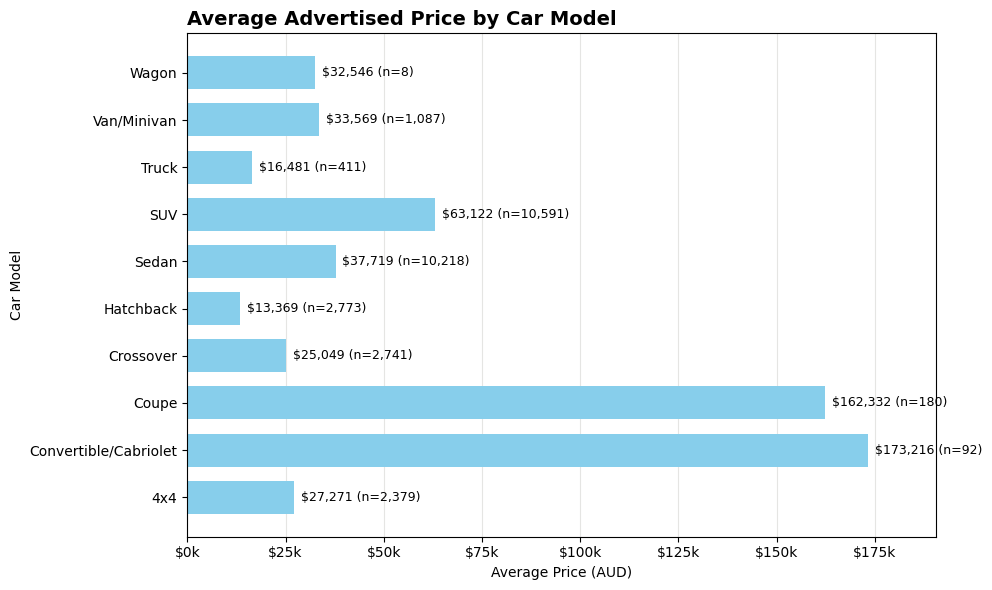

In [ ]:


# 4a-ii average price by car model

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# average price for each car model, plus median and count for context

model_price = (cleaned_car_data.groupby('car_model')['price (AUD)'].agg(mean_price='mean', median_price='median', n='size'))

# tidy up display names

name_fix = {'suv': 'SUV', '4x4': '4x4', 'van/minivan': 'Van/Minivan', 'convertible/cabriolet': 'Convertible/Cabriolet'}
model_price.index = [name_fix.get(m.lower(), m.title()) for m in model_price.index]

# print table behind chart

display(model_price.round(0).sort_values('mean_price', ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))

# horizontal bars

bars = ax.barh(model_price.index, model_price['mean_price'], color='skyblue', height=0.7)

# label each bar
for bar, (mean_p, n) in zip(bars, model_price[['mean_price', 'n']].values):
  ax.text(bar.get_width() + model_price['mean_price'].max() * 0.01, bar.get_y() + bar.get_height() / 2,
    f"${mean_p:,.0f} (n={int(n):,})", va='center', fontsize = 9, color='black')

ax.set_title('Average Advertised Price by Car Model', fontsize=14, fontweight='bold', loc='left')
ax.set_xlabel('Average Price (AUD)')
ax.set_ylabel('Car Model')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1000:,.0f}k"))
ax.set_xlim(0, model_price['mean_price'].max() * 1.1)

# recessive grid + axes

ax.grid(axis='x', color='#e5e5e3', linewidth=0.8)
ax.set_axisbelow(True)
for side in ['top', 'right']:
  ax.spines[side]

plt.tight_layout()
plt.show()

## 4a-iii engine_capacity Distribution

Electric cars excluded: 297
Missing engine capacity excluded: 1308
Engines plotted: 28869
Engines above 7.0 L (not shown): 6
count    28875.00
mean         2.06
std          0.80
min          0.20
25%          1.50
50%          2.00
75%          2.40
max         12.70
Name: engine_capacity, dtype: float64


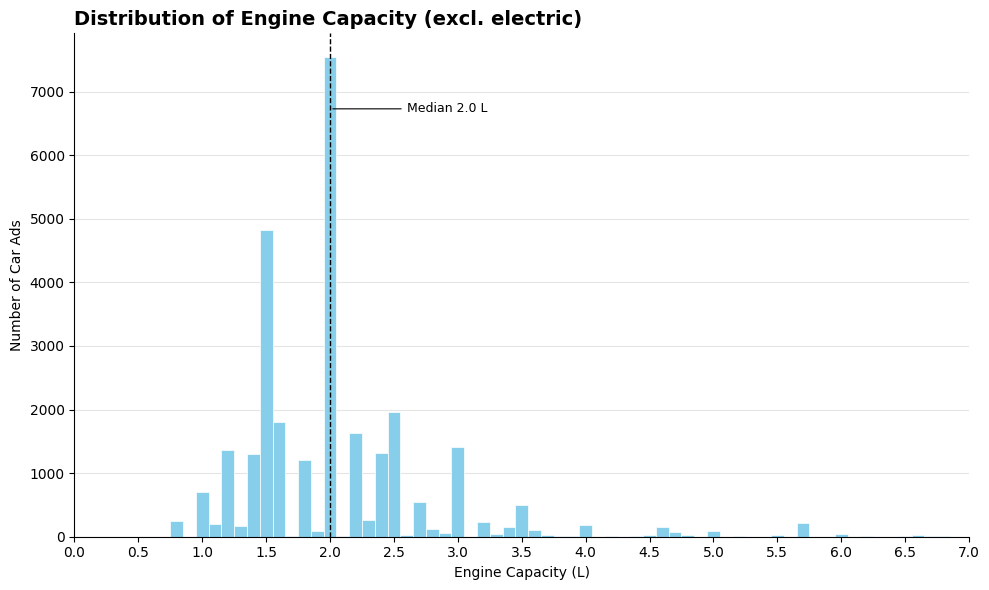

In [28]:
# engine_capacity distribution

import matplotlib.pyplot as plt

# electric cars list a placeholder 0.1, 0.2L

is_electric = cleaned_car_data['type_of_engine'].astype(str).str.lower() == 'electric'
engine_cap = cleaned_car_data.loc[~is_electric, 'engine_capacity'].dropna()

# extreme values stay in the stats but are cut from the view

view_max = 7.0
print("Electric cars excluded:", is_electric.sum())
print("Missing engine capacity excluded:", cleaned_car_data.loc[~is_electric, 'engine_capacity'].isna().sum())
print("Engines plotted:", (engine_cap <= view_max).sum())
print(f"Engines above {view_max} L (not shown):", (engine_cap > view_max).sum())
print(engine_cap.describe().round(2))

fig, ax = plt.subplots(figsize=(10, 6))

# capacities are recorded to 0.1L, so 0.1L bins centred on each value give every size its own bar

bins = np.arange(0.05, view_max + 0.1, 0.1)
ax.hist(engine_cap[engine_cap <= view_max], bins=bins, color='skyblue', edgecolor='white', linewidth=0.5)

# median reference line

median_cap = engine_cap.median()
ax.axvline(median_cap, color='black', linestyle='--', linewidth=1)
ax.annotate(f"Median {median_cap:.1f} L", xy=(median_cap, ax.get_ylim()[1] * 0.85), xytext=(median_cap + 0.6, ax.get_ylim()[1] * 0.85),
            fontsize=9, color='black', va='center', arrowprops=dict(arrowstyle='-', color='black', linewidth=0.8))

ax.set_title('Distribution of Engine Capacity (excl. electric)', fontsize=14, fontweight='bold', loc='left')
ax.set_xlabel('Engine Capacity (L)')
ax.set_ylabel('Number of Car Ads')
ax.set_xlim(0, view_max)
ax.set_xticks(np.arange(0, view_max + 0.5, 0.5))

# recessive grid + axes

ax.grid(axis='y', color='#e5e5e3', linewidth=0.8)
ax.set_axisbelow(True)
for side in ['top', 'right']:
  ax.spines[side].set_visible(False)

plt.tight_layout()
plt.show()